In [68]:
import os
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

In [69]:
script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..', '..')

forms_data_filename = 'processed_pre_post_forms.parquet'
forms_data_path = os.path.join(project_path, 'data', 'forms', 'processed_data', forms_data_filename)

interactions_data_filename = 'interactions_processed_data.parquet'
interactions_data_path = os.path.join(project_path, 'data', 'interactions', 'processed_data', interactions_data_filename)

In [70]:
forms_df = pl.read_parquet(forms_data_path)
interactions_df = pl.read_parquet(interactions_data_path)

In [71]:
base_cols = ['id', 'centro', 'grupo']

metrics = [
    'puntuacion_tc', 
    'puntuacion_ta', 
    'puntuacion_tcc_rel', 
    'puntuacion_tcc_int', 
    'puntuacion_tcc_ext', 
    'puntuacion_tc_retencion', 
    'puntuacion_tc_transferencia'
]

hake_metrics = [
    'puntuacion_tc_hake_gain', 
    'puntuacion_tc_retencion_hake_gain', 
    'puntuacion_tc_transferencia_hake_gain'
]

forms_cols_analysis = base_cols + hake_metrics + [
    f"{metric}{cat_suffix}_{period}"
    for period in ['pre', 'post']
    for cat_suffix in ['', '_cat']
    for metric in metrics
] 

In [72]:
forms_df = forms_df[forms_cols_analysis]

In [73]:
forms_interactions_df = forms_df.join(interactions_df, how='left', on='id')

In [74]:
forms_interactions_df['grupo'].value_counts()

grupo,count
str,u32
"""control""",96
"""experimental""",95
null,1


In [75]:
forms_interactions_df.filter(pl.col('grupo').is_null())

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tcc_rel_pre,puntuacion_tcc_int_pre,puntuacion_tcc_ext_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tcc_rel_cat_pre,puntuacion_tcc_int_cat_pre,puntuacion_tcc_ext_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use
str,str,str,f64,f64,f64,f64,f64,null,null,null,f64,f64,str,str,null,null,null,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool
"""Laguna-i9p""","""Laguna""",null,-0.2,0.0,-0.5,0.5,0.45,null,null,null,0.4,0.6,"""Bajo""","""Medio""",null,null,null,"""Bajo""","""Medio""",0.4,0.43,0.5,0.5,0.5,0.4,0.4,"""Bajo""","""Bajo""","""Bajo""","""Alto""","""Alto""","""Bajo""","""Bajo""",null,null,null,null,null,null,null,null,null


In [76]:
forms_interactions_df

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tcc_rel_pre,puntuacion_tcc_int_pre,puntuacion_tcc_ext_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tcc_rel_cat_pre,puntuacion_tcc_int_cat_pre,puntuacion_tcc_ext_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use
str,str,str,f64,f64,f64,f64,f64,null,null,null,f64,f64,str,str,null,null,null,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool
"""RamiroMaeztu-ks0""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,0.6,0.2,null,null,null,0.8,0.4,"""Medio""","""Bajo""",null,null,null,"""Medio""","""Bajo""",1.0,0.4,0.8,0.43,0.27,1.0,1.0,"""Alto""","""Bajo""","""Medio""","""Medio""","""Bajo""","""Medio""","""Alto""",2,5,true,true,true,"""Lower_Intermediate""",1.5,"""Lower_Intermediate""",false
"""RamiroMaeztu-pu9""","""RamiroMaeztu""","""experimental""",1.0,0.0,1.0,0.8,0.48,null,null,null,1.0,0.6,"""Alto""","""Medio""",null,null,null,"""Alto""","""Medio""",1.0,0.55,0.2,0.4,0.27,1.0,1.0,"""Alto""","""Medio""","""Bajo""","""Medio""","""Bajo""","""Medio""","""Alto""",8,5,false,true,true,"""High""",1.625,"""Lower_Intermediate""",false
"""RamiroMaeztu-8jb""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,0.6,0.45,null,null,null,0.6,0.6,"""Medio""","""Medio""",null,null,null,"""Bajo""","""Medio""",1.0,0.4,0.57,0.6,0.47,1.0,1.0,"""Alto""","""Bajo""","""Bajo""","""Alto""","""Medio""","""Medio""","""Alto""",7,5,true,true,true,"""High""",2.571429,"""High""",false
"""RamiroMaeztu-x5e""","""RamiroMaeztu""","""experimental""",0.0,-2.0,0.666667,0.6,0.7,null,null,null,0.8,0.4,"""Medio""","""Alto""",null,null,null,"""Medio""","""Bajo""",0.6,0.43,0.63,0.53,0.63,0.4,0.8,"""Bajo""","""Bajo""","""Bajo""","""Alto""","""Alto""","""Bajo""","""Bajo""",0,5,false,false,true,"""Not_Used""",null,null,false
"""RamiroMaeztu-80a""","""RamiroMaeztu""","""experimental""",0.5,0.0,0.5,0.8,0.52,null,null,null,1.0,0.6,"""Alto""","""Alto""",null,null,null,"""Alto""","""Medio""",0.9,0.6,0.9,0.3,0.27,1.0,0.8,"""Medio""","""Alto""","""Alto""","""Medio""","""Bajo""","""Medio""","""Bajo""",0,5,false,false,true,"""Not_Used""",null,null,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Laguna-r45""","""Laguna""","""experimental""",0.0,-1.0,0.5,0.7,0.35,null,null,null,0.8,0.6,"""Medio""","""Bajo""",null,null,null,"""Medio""","""Medio""",0.7,0.6,0.63,0.47,0.43,0.6,0.8,"""Bajo""","""Alto""","""Bajo""","""Medio""","""Medio""","""Bajo""","""Bajo""",3,5,true,true,true,"""Upper_Intermediate""",1.333333,"""Low""",false
"""Laguna-lqw""","""Laguna""","""experimental""",0.4,0.5,0.333333,0.5,0.52,null,null,null,0.6,0.4,"""Bajo""","""Alto""",null,null,null,"""Bajo""","""Bajo""",0.7,0.6,0.93,0.53,0.2,0.8,0.6,"""Bajo""","""Alto""","""Alto""","""Alto""","""Bajo""","""Bajo""","""Bajo""",2,5,false,true,true,"""Lower_Intermediate""",1.0,"""Low""",false
"""Laguna-chn""","""Laguna""","""experimental""",0.2,-2.0,0.75,0.5,0.52,null,null,null,0.8,0.2,"""Bajo""","""Alto""",null,null,null,"""Medio""","""Bajo""",0.6,0.58,0.93,0.27,0.33,0.4,0.8,"""Bajo""","""Alto""","""Alto""","""Bajo""","""Medio""","""Bajo""","""Bajo""",4,5,false,true,true,"""Upper_Intermediate""",0.0,"""Not_Relevant""",false


In [77]:
forms_interactions_df.filter(pl.col('grupo') == 'control').group_by(['centro', 'WSDI_cat']).agg(pl.len())

centro,WSDI_cat,len
str,str,u32
"""JesusMaria""",null,27
"""JoseGarciaNieto""",null,14
"""Laguna""",null,24
"""RamiroMaeztu""",null,31


In [78]:
forms_interactions_df.filter(
    (pl.col('grupo') == 'experimental') & 
    (pl.col('centro') == 'Laguna')
).group_by(['centro', 'WSDI_cat']).agg(pl.len())

centro,WSDI_cat,len
str,str,u32
"""Laguna""","""Not_Relevant""",1
"""Laguna""","""Lower_Intermediate""",4
"""Laguna""","""Low""",7
"""Laguna""","""Upper_Intermediate""",3
"""Laguna""",null,8


In [79]:
forms_interactions_df.filter(
    (pl.col('grupo') == 'experimental') &
    (pl.col('centro') == 'Laguna') &
    (~ pl.col('WSDI_cat').is_null()) 
)

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tcc_rel_pre,puntuacion_tcc_int_pre,puntuacion_tcc_ext_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tcc_rel_cat_pre,puntuacion_tcc_int_cat_pre,puntuacion_tcc_ext_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use
str,str,str,f64,f64,f64,f64,f64,null,null,null,f64,f64,str,str,null,null,null,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool
"""Laguna-4kk""","""Laguna""","""experimental""",-1.0,-3.0,-0.333333,0.6,0.55,null,null,null,0.8,0.4,"""Medio""","""Alto""",null,null,null,"""Medio""","""Bajo""",0.2,0.15,0.5,0.6,0.67,0.2,0.2,"""Bajo""","""Bajo""","""Bajo""","""Alto""","""Alto""","""Bajo""","""Bajo""",4,5,true,true,true,"""Upper_Intermediate""",2.0,"""Upper_Intermediate""",false
"""Laguna-hxh""","""Laguna""","""experimental""",0.75,0.0,1.0,0.6,0.52,null,null,null,1.0,0.2,"""Medio""","""Alto""",null,null,null,"""Alto""","""Bajo""",0.9,0.35,0.67,0.6,0.67,0.8,1.0,"""Medio""","""Bajo""","""Bajo""","""Alto""","""Alto""","""Bajo""","""Alto""",7,5,false,true,true,"""High""",0.857143,"""Low""",false
"""Laguna-ioy""","""Laguna""","""experimental""",0.833333,1.0,0.5,0.4,0.5,null,null,null,0.2,0.6,"""Bajo""","""Medio""",null,null,null,"""Bajo""","""Medio""",0.9,0.38,0.43,0.67,0.77,1.0,0.8,"""Medio""","""Bajo""","""Bajo""","""Alto""","""Alto""","""Medio""","""Bajo""",4,5,true,true,true,"""Upper_Intermediate""",2.0,"""Upper_Intermediate""",false
"""Laguna-2uy""","""Laguna""","""experimental""",0.0,0.0,0.0,0.8,0.35,null,null,null,0.8,0.8,"""Alto""","""Bajo""",null,null,null,"""Medio""","""Alto""",0.8,0.5,0.87,0.37,0.2,0.8,0.8,"""Medio""","""Medio""","""Alto""","""Medio""","""Bajo""","""Bajo""","""Bajo""",4,5,false,true,true,"""Upper_Intermediate""",1.75,"""Lower_Intermediate""",false
"""Laguna-rjb""","""Laguna""","""experimental""",0.6,0.0,0.75,0.5,0.58,null,null,null,0.8,0.2,"""Bajo""","""Alto""",null,null,null,"""Medio""","""Bajo""",0.8,0.7,0.9,0.2,0.37,0.8,0.8,"""Medio""","""Alto""","""Alto""","""Bajo""","""Medio""","""Bajo""","""Bajo""",7,5,true,true,true,"""High""",1.857143,"""Lower_Intermediate""",false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Laguna-chk""","""Laguna""","""experimental""",-3.0,0.0,0.0,0.9,0.5,null,null,null,1.0,0.8,"""Alto""","""Medio""",null,null,null,"""Alto""","""Alto""",0.6,0.48,0.6,0.8,0.8,0.4,0.8,"""Bajo""","""Medio""","""Bajo""","""Alto""","""Alto""","""Bajo""","""Bajo""",5,5,false,true,true,"""High""",1.6,"""Lower_Intermediate""",false
"""Laguna-4fh""","""Laguna""","""experimental""",0.0,0.0,0.666667,0.7,0.4,null,null,null,1.0,0.4,"""Medio""","""Bajo""",null,null,null,"""Alto""","""Bajo""",0.7,0.4,0.5,0.5,0.5,0.6,0.8,"""Bajo""","""Bajo""","""Bajo""","""Alto""","""Alto""","""Bajo""","""Bajo""",2,5,false,true,true,"""Lower_Intermediate""",1.0,"""Low""",false
"""Laguna-r45""","""Laguna""","""experimental""",0.0,-1.0,0.5,0.7,0.35,null,null,null,0.8,0.6,"""Medio""","""Bajo""",null,null,null,"""Medio""","""Medio""",0.7,0.6,0.63,0.47,0.43,0.6,0.8,"""Bajo""","""Alto""","""Bajo""","""Medio""","""Medio""","""Bajo""","""Bajo""",3,5,true,true,true,"""Upper_Intermediate""",1.333333,"""Low""",false


In [80]:
forms_interactions_df.filter(
    (pl.col('grupo') == 'control') &
    (pl.col('centro') == 'Laguna') &
    (~ pl.col('WSDI_cat').is_null()) 
)

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tcc_rel_pre,puntuacion_tcc_int_pre,puntuacion_tcc_ext_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tcc_rel_cat_pre,puntuacion_tcc_int_cat_pre,puntuacion_tcc_ext_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use
str,str,str,f64,f64,f64,f64,f64,null,null,null,f64,f64,str,str,null,null,null,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool


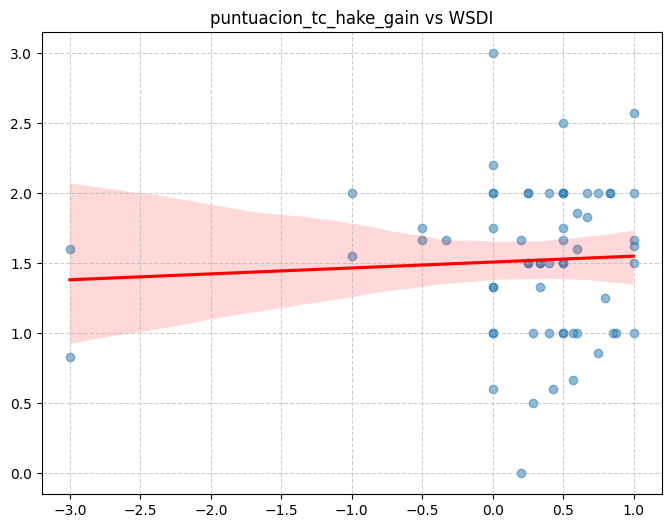

In [ ]:
plt.figure(figsize=(8, 6))
sns.regplot(
    data=forms_interactions_df,  
    x='puntuacion_tc_hake_gain', 
    y='WSDI',
    scatter_kws={'alpha':0.5}, # Transparencia para ver puntos solapados
    line_kws={'color':'red'}   # Línea de tendencia
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()